In [21]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt
from scipy.fft import fft, fftfreq

In [22]:
a1 = 0.8
SigmaW = 1
SigmaV = 1
N = 500
p = 2
worder = p-1
np.random.seed(0)
wn = SigmaW*np.random.normal(0,1,N)
vn = SigmaV*np.random.normal(0,1,N)
d = signal.lfilter(1, np.array([1, -a1]), wn)
d = d/np.sqrt(np.sum(d**2)/N)
x = d + vn

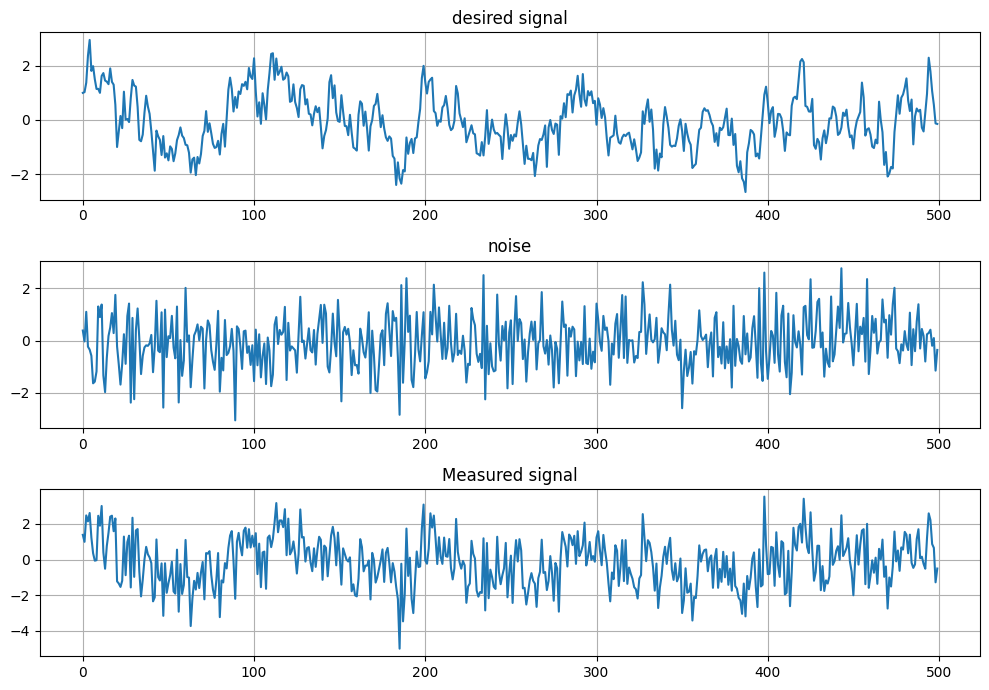

In [23]:
fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(3, 1, 1)

ax1.plot(d)
ax1.set_title('desired signal')
ax1.grid(True)

ax2 = fig.add_subplot(3, 1, 2)

ax2.plot(vn)
ax2.set_title('noise')
ax2.grid(True)

ax3 = fig.add_subplot(3, 1, 3)

ax3.plot(x)
ax3.set_title('Measured signal')
ax3.grid(True)

fig.tight_layout()
plt.show()

In [24]:
def wienerFilterTheo(sigmaV, a, order):
    p = order + 1
    k = np.arange(0, p)
    rv = sigmaV**2
    Rv = rv*np.eye(p)
    rd = a**k
    Rd = toeplitz(rd, rd)
    Rx = Rd + Rv
    w = np.linalg.solve(Rx, rd)
    E = rd[0]- (w @ rd)
    return w,E,rd,Rd,Rv,Rx

In [25]:
w,E,rd,Rd,Rv,Rx = wienerFilterTheo(SigmaV, a1, worder)

print("Rx =", Rx)
print("Rv =", Rv)
print("Rd =", Rd)
print("Wtheo =", w)
print("E =", E)

Rx = [[2.  0.8]
 [0.8 2. ]]
Rv = [[1. 0.]
 [0. 1.]]
Rd = [[1.  0.8]
 [0.8 1. ]]
Wtheo = [0.4047619  0.23809524]
E = 0.40476190476190477


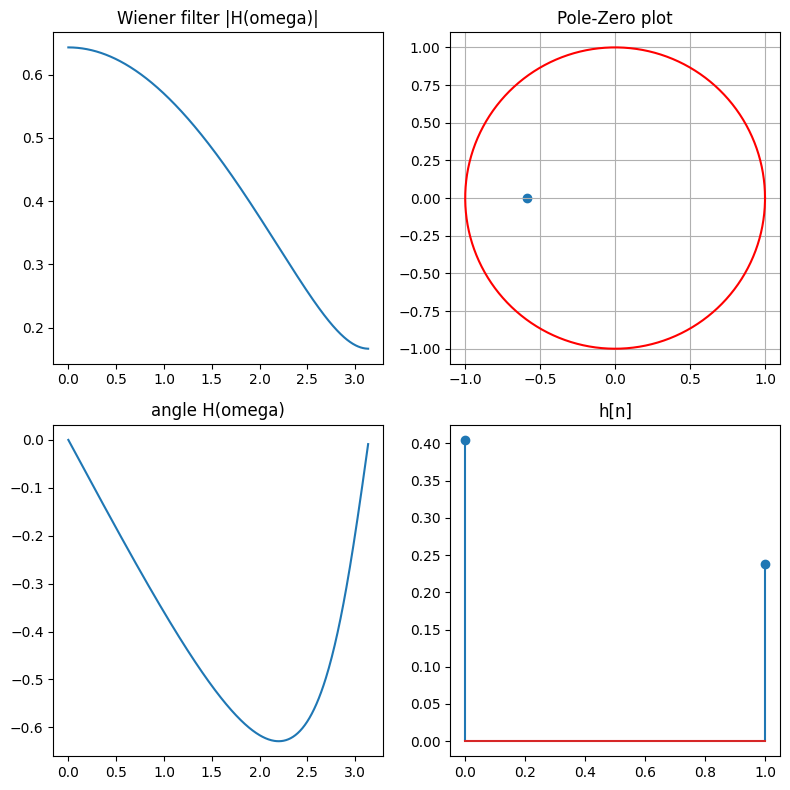

In [26]:
frequencies, H = freqz(w, worN=512)
H_abs = np.abs(H)
H_angle = np.angle(H)
zeros, poles, k = tf2zpk(w, [1])


fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(frequencies, H_abs)
ax1.set_title('Wiener filter |H(omega)|')

ax2 = fig.add_subplot(2, 2, 2)
theta = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta), np.sin(theta), 'r-')
ax2.scatter(zeros.real, zeros.imag, marker='o')
ax2.scatter(poles.real, poles.imag, marker='x')
ax2.set_title('Pole-Zero plot')
plt.grid()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(frequencies, H_angle)
ax3.set_title('angle H(omega)')

ax4 = fig.add_subplot(2, 2, 4)
ax4.stem(np.arange(len(w)), w)
ax4.set_title('h[n]')

fig.tight_layout()
plt.show()

In [27]:
dhat = signal.lfilter(w, 1, x)

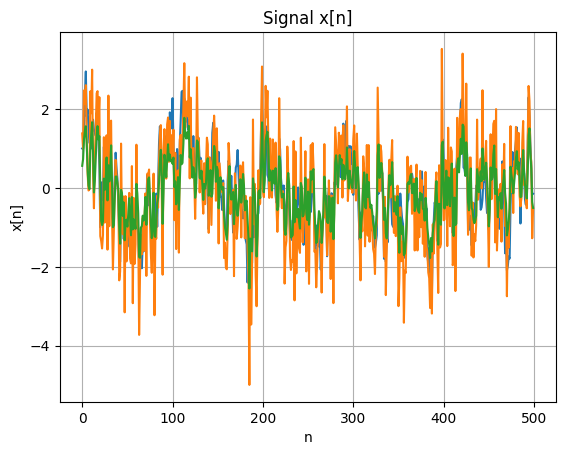

In [28]:
plt.figure()
plt.plot(d)
plt.plot(x)
plt.plot(dhat)
plt.title('Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

In [29]:
Ed = w@Rd@w
Ev = w@Rv@w
snr = 10*np.log10(Ed/Ev)
print("SNR after filtering :", snr)

SNR after filtering : 2.3025185815993248


In [ ]:
def wiener_fir(x, d, order):
    p = order + 1

    rdx = a**k

    Rx = 
    w = np.linalg.solve(Rx, rd)
    E = rd[0]- (w @ rd)
    return w,E,rd,Rd,Rv,Rx